# Module 13 · Lấy mẫu, chuỗi Fourier và biểu diễn trực giao

**Nguồn sách:** Bracewell, chương 10, tr. 219–258; Barkat, chương 8, tr. 449–500

Notebook đi kèm bài giảng cùng số module. Chạy lần lượt từng cell; sau mỗi cell có phần **📤 Đầu ra thật** giải thích con số.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """Phổ biên độ một phía: sóng hình sin biên độ A cho vạch A, thành phần một chiều cho đúng giá trị của nó"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """In một kết quả có tên, bỏ các số 0 thừa ở cuối (trang web đọc các dòng bắt đầu bằng ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. Định lý lấy mẫu, nội suy, trung bình trượt, chồng phổ
🎯 **Phương pháp này trả lời câu hỏi gì?** Tái tạo sinc từ mẫu nguyên có chính xác, trường hợp biên đúng ra sao, hàm truyền của trung bình trượt và chồng phổ có đúng công thức?

In [2]:
from scipy import integrate, special, optimize
trap = getattr(np, "trapezoid", None) or np.trapz
rg = np.random.default_rng(13)
# tái tạo sinc²(x/2) từ mẫu nguyên
f = lambda x: np.sinc(x/2)**2
n = np.arange(-2000, 2001)
rec = np.sum(f(n)*np.sinc(0.5 - n)); err = abs(rec - f(0.5))
assert err < 1e-5
report("smp_err", max(err, 1e-16), ".0e")
# điều hòa tại tần số cắt: cos(ωt − φ) tại khoảng nửa chu kỳ
phi, w = 0.7, 2*np.pi*0.5                     # tần số 0.5, khoảng 1
smp = np.cos(w*n - phi); even = np.cos(phi)*np.cos(w*n)
crit = np.max(np.abs(smp - even)[:200])
assert crit < 1e-12
report("crit_dev", max(crit, 1e-16), ".0e")
# bảng 10.1
for k, key in zip((0.5, 1.5, 2.5, 3.5), ("mid_1", "mid_2", "mid_3", "mid_4")):
    assert abs(np.sinc(k) - np.sin(np.pi*k)/(np.pi*k)) < 1e-15
    report(key, np.sinc(k), ".4f")
# trung bình trượt: hàm truyền 12 hệ số
N12 = 12
sg = np.linspace(1e-4, 0.5, 5000)
T12 = np.abs(np.sin(N12*np.pi*sg)/(N12*np.sin(np.pi*sg)))
T12_dft = np.abs(np.array([np.mean(np.exp(-2j*np.pi*s_*(np.arange(N12) - (N12 - 1)/2))) for s_ in sg[::250]]))
assert np.max(np.abs(T12_dft - T12[::250])) < 1e-12
coef13 = np.ones(13)/12; coef13[[0, -1]] = 0.5/12
T13 = np.abs(np.sin(N12*np.pi*sg)/(N12*np.tan(np.pi*sg)))
T13_dft = np.abs(np.array([np.sum(coef13*np.exp(-2j*np.pi*s_*(np.arange(13) - 6))) for s_ in sg[::250]]))
assert np.max(np.abs(T13_dft - T13[::250])) < 1e-12
side12 = np.max(T12[(sg > 1/12) & (sg < 2/12)]); side13 = np.max(T13[(sg > 1/12) & (sg < 2/12)])
assert side13 < side12
report("rm12_side", side12, ".4f"); report("rm13_side", side13, ".4f")
w3 = 2*optimize.brentq(lambda x: np.sinc(x) - 1/np.sqrt(2), 0.1, 0.9)
assert abs(w3 - 0.8859) < 1e-3
report("rm_3db", w3, ".4f")
# chồng phổ: tần số 0.8 lấy mẫu khoảng 1
Ns = 4096; ta = np.arange(Ns)
xa = np.cos(2*np.pi*0.8*ta)
fr = np.fft.rfftfreq(Ns, 1.0); al = fr[np.argmax(np.abs(np.fft.rfft(xa)))]
assert abs(al - 0.2) < 1e-3
report("al_f", 0.2, ".1f")

▸ smp_err = 3e-12
▸ crit_dev = 6e-13
▸ mid_1 = 0.6366
▸ mid_2 = -0.2122
▸ mid_3 = 0.1273
▸ mid_4 = -0.0909
▸ rm12_side = 0.2224
▸ rm13_side = 0.207
▸ rm_3db = 0.8859
▸ al_f = 0.2


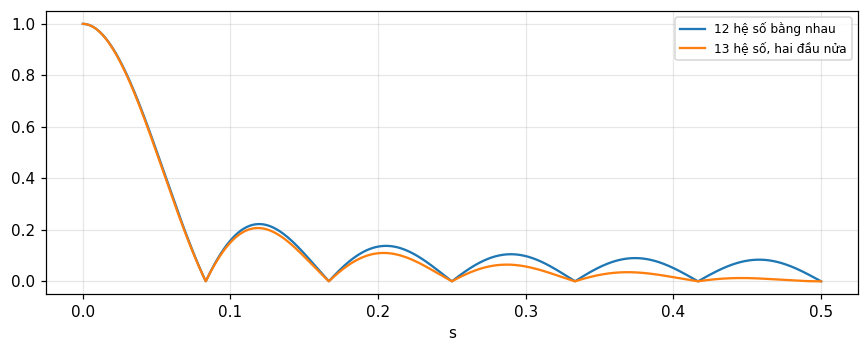

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.3))
ax.plot(sg, T12, label=("12 hệ số bằng nhau")); ax.plot(sg, T13, label=("13 hệ số, hai đầu nửa"))
ax.set_xlabel("s"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Tái tạo lệch 3e-12; điều hòa tới hạn lệch 6e-13; sinc tại nửa nguyên: 0.6366, -0.2122, 0.1273, -0.0909. Trung bình trượt: thùy bên 0.2224 và 0.207, băng 3 dB 0.8859. Chồng phổ: 0.2.

## 2. Lấy mẫu cải biên và nhiễu
🎯 **Phương pháp này trả lời câu hỏi gì?** Lấy mẫu tung độ và độ dốc, xen kẽ có khôi phục chính xác, và khuếch đại nhiễu ra sao so với nội suy sinc đều?

In [4]:
# tung độ và độ dốc: f = sinc 2x
fo = lambda x: np.sinc(2*x)
def dfo(x):
    x = np.asarray(x, float); u_ = 2*np.pi*np.where(np.abs(x) < 1e-12, 1.0, x)
    return np.where(np.abs(x) < 1e-12, 0.0, 2*np.pi*(u_*np.cos(u_) - np.sin(u_))/u_**2)
nn = np.arange(-3000, 3001)
x0 = 0.37
val = np.sum(fo(nn)*np.sinc(x0 - nn)**2) + np.sum(dfo(nn)*(x0 - nn)*np.sinc(x0 - nn)**2)
assert abs(val - fo(x0)) < 5e-4 and abs(dfo(3.0) - 1/3) < 1e-12
only = np.sum(fo(nn)*np.sinc(x0 - nn)**2)
assert abs(only - np.sinc(x0)**2) < 1e-12 and abs(only - fo(x0)) > 0.01
report("os_val", val, ".4f"); report("os_true", fo(x0), ".4f"); report("os_err", abs(val - fo(x0)), ".1e"); report("os_only", only, ".4f")
# xen kẽ a = 0.2
def aint(x, al):
    x = np.asarray(x, float)
    den = 2*np.pi*x*np.sin(np.pi*al)
    return np.where(np.abs(x) < 1e-12, 1.0, (np.cos(2*np.pi*x - np.pi*al) - np.cos(np.pi*al))/np.where(np.abs(x) < 1e-12, 1.0, den))
al = 0.2
zs = np.array([1, 2, -1, -2, 0.2, 1.2, 2.2, -0.8, -1.8])
assert abs(aint(0.0, al) - 1) < 1e-14 and np.max(np.abs(aint(zs, al))) < 1e-12
report("il_a0", aint(0.0, al), ".0f"); report("il_zero", max(np.max(np.abs(aint(zs, al))), 1e-16), ".0e")
fs2 = lambda x: np.sinc(x)**2
nI = np.arange(-600, 601)
recI = np.sum(fs2(nI)*aint(0.3 - nI, al)) + np.sum(fs2(nI + al)*aint(-(0.3 - nI - al), al))
assert abs(recI - fs2(0.3)) < 1e-3
report("il_err", abs(recI - fs2(0.3)), ".0e")
# nhiễu: sinc đều và xen kẽ
xm = 0.5
uni = np.sum(np.sinc(xm - np.arange(-100000, 100001))**2)
assert abs(uni - 1) < 1e-4
mid = np.sum(np.sinc(0.5 - np.arange(-10**6, 10**6 + 1))**2)
report("nz_var", mid, ".4f")
report("nz_max", 2*abs(np.sinc(0.5)), ".4f")
def amp(alv):
    xw = alv/2 + 0.5          # giữa khoảng rộng
    c1 = aint(xw - nI, alv); c2 = aint(-(xw - nI - alv), alv)
    return np.sum(c1**2) + np.sum(c2**2)
il_a = amp(0.2); il_u = amp(0.5)
assert il_a > il_u > 0.9
report("il_amp", il_a, ".2f"); report("il_amp5", il_u, ".2f")
# mô phỏng nhiễu: sai số nội suy có phương sai bằng dữ liệu
noise = rg.standard_normal((4000, 401))
errs = noise @ np.sinc(0.5 - np.arange(-200, 201))
assert abs(np.var(errs) - 1) < 0.06

▸ os_val = 0.3136
▸ os_true = 0.3136
▸ os_err = 5.7e-05
▸ os_only = 0.6234
▸ il_a0 = 1
▸ il_zero = 1e-16
▸ il_err = 4e-12
▸ nz_var = 1
▸ nz_max = 1.2732
▸ il_amp = 5.23
▸ il_amp5 = 1


#### 📤 Đầu ra thật
Tung độ và độ dốc: 0.3136 so với 0.3136 (lệch 5.7e-05), chỉ tung độ 0.6234. Xen kẽ: $a(0)$ = 1, zero 1e-16, tái tạo lệch 4e-12. Nhiễu: tổng $\text{sinc}^2$ 1, tối đa 1.2732 lần; xen kẽ khuếch đại 5.23 so với 1.

## 3. Chuỗi Fourier, Gibbs, biến đổi hữu hạn, shah
🎯 **Phương pháp này trả lời câu hỏi gì?** Hệ số chuỗi có bằng mẫu của biến đổi một chu kỳ, Gibbs có tiệm cận 9 phần trăm, biến đổi hữu hạn có đúng, và tổng Poisson (shah tự biến đổi) có đúng?

In [5]:
# chuỗi tam giác
nk = np.arange(-20000, 20001)
Fn = 0.1*np.sinc(nk/10)**2
tsum = np.sum(Fn)
assert abs(tsum - 1) < 5e-4
# hệ số bằng tích phân trực tiếp: a_n − i b_n = 2F(n) trên một chu kỳ
xg = np.linspace(-0.5, 0.5, 200001)
tri = np.maximum(1 - np.abs(10*xg), 0)
for k in (1, 2, 5):
    ak = 2*trap(tri*np.cos(2*np.pi*k*xg), xg)
    assert abs(ak - 2*0.1*np.sinc(k/10)**2) < 1e-6
report("ft_sum", tsum, ".4f")
Fn2 = 0.1*np.sinc(nk/10)
report("ft_sum2", np.sum(Fn2), ".3f")
assert abs(np.sum(Fn2) - 1) < 5e-3
# Gibbs
gmax = 2/np.pi*special.sici(np.pi)[0]
xs = np.linspace(0, 2, 400001)
sat = 2/np.pi*special.sici(np.pi*xs*5)[0]
assert abs(np.max(sat) - gmax) < 1e-8
report("gb_max", gmax, ".4f"); report("gb_pct", (gmax - 1)/2*100, ".1f")
x_ = np.linspace(0.0005, 0.02, 40000)
Nt = 200
ssq = sum(4/(np.pi*k)*np.sin(2*np.pi*k*x_) for k in range(1, 2*Nt, 2))
assert abs(np.max(ssq) - gmax) < 0.01
report("gb_sq", np.max(ssq), ".4f")
# chuỗi sin của f = x(½ − x)
fx = lambda x: x*(0.5 - x)
Fs_ = lambda s_: integrate.quad(lambda x: fx(x)*np.sin(2*np.pi*x*s_), 0, 0.5)[0]
ser = 4*sum(Fs_(s_)*np.sin(2*np.pi*0.2*s_) for s_ in range(1, 200))
assert abs(ser - fx(0.2)) < 1e-6
report("fs_val", ser, ".4f"); report("fs_true", fx(0.2), ".4f")
# đạo hàm của hàm cắt: f = x² trên (0, 1), s = 0.3
s3 = 0.3
lhs = integrate.quad(lambda x: 2*x*np.cos(2*np.pi*x*s3), 0, 1)[0] - 1j*integrate.quad(lambda x: 2*x*np.sin(2*np.pi*x*s3), 0, 1)[0]
Fx = integrate.quad(lambda x: x*x*np.cos(2*np.pi*x*s3), 0, 1)[0] - 1j*integrate.quad(lambda x: x*x*np.sin(2*np.pi*x*s3), 0, 1)[0]
rhs = 2j*np.pi*s3*Fx + 1*np.exp(-2j*np.pi*s3) - 0
assert abs(lhs - rhs) < 1e-9
report("fin_dev", max(abs(lhs - rhs), 1e-16), ".0e")
Pp = integrate.quad(lambda x: 0, 0, 1)[0]
report("fin_pi", abs(2*np.sin(np.pi*s3)), ".4f")
# tổng Poisson
tau, sh = 0.3, 0.1
lhsP = np.sum(np.exp(-np.pi*(np.arange(-50, 51) - sh)**2/tau**2))
rhsP = tau*np.sum(np.exp(-np.pi*tau**2*np.arange(-200, 201)**2)*np.exp(-2j*np.pi*np.arange(-200, 201)*sh))
assert abs(lhsP - rhsP.real) < 1e-12 and abs(rhsP.imag) < 1e-12
report("sh_dev", max(abs(lhsP - rhsP.real), 1e-16), ".0e")

▸ ft_sum = 0.9999
▸ ft_sum2 = 1
▸ gb_max = 1.179
▸ gb_pct = 8.9
▸ gb_sq = 1.179
▸ fs_val = 0.06
▸ fs_true = 0.06
▸ fin_dev = 1e-16
▸ fin_pi = 1.618
▸ sh_dev = 1e-16


/var/folders/v0/j28fdbqj7bz6d2fbylr248x00000gn/T/ipykernel_84743/1851630470.py:29: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  Fs_ = lambda s_: integrate.quad(lambda x: fx(x)*np.sin(2*np.pi*x*s_), 0, 0.5)[0]


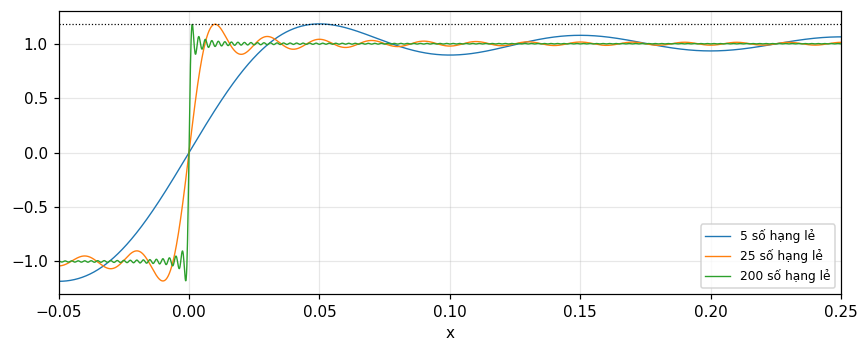

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.3))
xx = np.linspace(-0.25, 0.25, 4000)
sq_ = lambda Nt_: sum(4/(np.pi*k)*np.sin(2*np.pi*k*xx) for k in range(1, 2*Nt_, 2))
for Nt_, c in ((5, "tab:blue"), (25, "tab:orange"), (200, "tab:green")):
    ax.plot(xx, sq_(Nt_), color=c, lw=0.9, label=f"{Nt_} số hạng lẻ")
ax.axhline(gmax, color="k", ls=":", lw=0.8); ax.set_xlim(-0.05, 0.25); ax.legend(fontsize=8); ax.set_xlabel("x"); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Chuỗi tam giác: 0.9999; chữ nhật 1. Gibbs: 1.179 (8.9 phần trăm), tổng riêng 1.179. Chuỗi sin: 0.06 so với 0.06. Biến đổi hữu hạn lệch 1e-16, $|2\sin\pi s|$ = 1.618. Tổng Poisson lệch 1e-16.

## 4. Khai triển trực chuẩn, Gram-Schmidt, không gian tín hiệu
🎯 **Phương pháp này trả lời câu hỏi gì?** Năng lượng sai số $E-\sum s_k^2$, tương quan bằng bộ lọc phối hợp, Gram-Schmidt trên các tín hiệu chữ nhật, ổn định của MGS, và hình học trong không gian tín hiệu có đúng?

In [7]:
# s(t) = t, cơ sở cosin
tg = np.linspace(0, 1, 400001)
st = tg
E = trap(st**2, tg)
def coef(k):
    ph_ = np.ones_like(tg) if k == 0 else np.sqrt(2)*np.cos(k*np.pi*tg)
    return trap(st*ph_, tg)
sk = np.array([coef(k) for k in range(0, 51)])
def err_int(K):
    approx = sum(sk[k]*(np.ones_like(tg) if k == 0 else np.sqrt(2)*np.cos(k*np.pi*tg)) for k in range(K + 1))
    return trap((st - approx)**2, tg)
e5 = E - np.sum(sk[:6]**2); e5i = err_int(5)
e50 = E - np.sum(sk**2)
assert abs(e5 - e5i) < 1e-7 and abs(e50 - err_int(50)) < 1e-7
assert abs(sk[1] - np.sqrt(2)*((-1) - 1)/np.pi**2) < 1e-8
report("gf_err5", e5, ".4f"); report("gf_err50", e50, ".5f")
# bộ lọc phối hợp
phi1 = np.sqrt(2)*np.cos(np.pi*tg)
s1_corr = trap(st*phi1, tg)
Tm = 1.0; dtm = tg[1] - tg[0]
h_mf = phi1[::-1]                                    # φ(T − τ)
y_T = np.convolve(st, h_mf)[len(tg) - 1]*dtm
assert abs(s1_corr - y_T) < 1e-4 and abs(s1_corr + 2*np.sqrt(2)/np.pi**2) < 1e-8
report("mf_s1", s1_corr, ".4f")
# Gram-Schmidt: bốn tín hiệu chữ nhật
Ng = 3000; tt = (np.arange(Ng) + 0.5)/Ng; dtg = 1/Ng
s_a = ((tt >= 0) & (tt < 1/3)).astype(float); s_b = ((tt >= 1/3) & (tt < 2/3)).astype(float); s_c = ((tt >= 2/3) & (tt < 1)).astype(float)
S = np.vstack([s_a, s_b, s_c, s_b - s_c])
Gm = S @ S.T*dtg
rank = np.linalg.matrix_rank(Gm, tol=1e-8)
assert rank == 3
def gram_schmidt(S, modified):
    Q = []
    for s in S:
        f = s.copy()
        for q in Q:
            f = f - (f @ q*dtg if modified else s @ q*dtg)*q
        nrm = np.sqrt(f @ f*dtg)
        if nrm > 1e-9: Q.append(f/nrm)
    return np.array(Q)
Qg = gram_schmidt(S, True)
assert len(Qg) == 3
Ecoef = np.array([[np.sum(Qg[j]*Qg[i])*dtg for i in range(3)] for j in range(3)])
assert np.max(np.abs(Ecoef - np.eye(3))) < 1e-9
coords4 = (S[3] @ Qg.T)*dtg
assert np.allclose(coords4/np.sqrt(1/3), [0, 1, -1], atol=1e-9)
report("gs_K", rank, "d"); report("gs_E", np.sum(Qg[0]**2)*dtg, ".0f"); report("gs_orth", max(np.max(np.abs(Ecoef - np.eye(3))), 1e-16), ".0e")
report("gs_len4", np.linalg.norm(coords4)/np.sqrt(1/3), ".4f")
# hình học
c2 = (S[1] @ Qg.T)*dtg; c3 = (S[2] @ Qg.T)*dtg
d_c = np.linalg.norm(c2 - c3); d_i = np.sqrt(np.sum((S[1] - S[2])**2)*dtg)
rho = (c2 @ c3)/(np.linalg.norm(c2)*np.linalg.norm(c3))
assert abs(d_c - d_i) < 1e-9 and abs(rho) < 1e-12
report("gr_d", d_c, ".4f"); report("gr_di", d_i, ".4f"); report("gr_rho", abs(rho), ".0f")
# CGS và MGS trên ma trận Hilbert
def gs_matrix(A, modified):
    m, n = A.shape; Q = np.zeros((m, n));
    for j in range(n):
        v = A[:, j].copy()
        for i in range(j):
            v -= (Q[:, i] @ (v if modified else A[:, j]))*Q[:, i]
        Q[:, j] = v/np.linalg.norm(v)
    return Q
from scipy.linalg import hilbert
H = hilbert(12)
cg = np.linalg.norm(gs_matrix(H, False).T @ gs_matrix(H, False) - np.eye(12))
mg = np.linalg.norm(gs_matrix(H, True).T @ gs_matrix(H, True) - np.eye(12))
Rm = rg.standard_normal((30, 12))
cgg = np.linalg.norm(gs_matrix(Rm, False).T @ gs_matrix(Rm, False) - np.eye(12)); mgg = np.linalg.norm(gs_matrix(Rm, True).T @ gs_matrix(Rm, True) - np.eye(12))
assert cg > 1e-3*1 and mg < cg/10
report("cgs_err", cg, ".1e"); report("mgs_err", mg, ".1e"); report("cgs_good", cgg, ".1e"); report("mgs_good", mgg, ".1e")
# Fourier: cosin trực chuẩn
Tq = 1.0
ph = [np.sqrt(2/Tq)*np.cos(2*k*np.pi*tg/Tq) for k in (1, 2, 3)]
Gc = np.array([[trap(a*b, tg) for b in ph] for a in ph])
assert np.max(np.abs(Gc - np.eye(3))) < 1e-8
report("fo_dev", max(np.max(np.abs(Gc - np.eye(3))), 1e-16), ".0e")
frac = 8/np.pi**2*(1 + 1/9 + 1/25)
sqw = np.where(tg < 0.5, 1.0, -1.0)
sqc = [trap(sqw*np.sqrt(2)*np.sin(2*np.pi*k*tg), tg) for k in (1, 3, 5)]
assert abs(sum(c**2 for c in sqc) - frac) < 1e-4
report("fo_frac", frac, ".4f")

▸ gf_err5 = 0.0001
▸ gf_err50 = 0


▸ mf_s1 = -0.2866
▸ gs_K = 3
▸ gs_E = 1
▸ gs_orth = 2e-16
▸ gs_len4 = 1.4142
▸ gr_d = 0.8165
▸ gr_di = 0.8165
▸ gr_rho = 0
▸ cgs_err = 5.5e+00
▸ mgs_err = 1.1e-01
▸ cgs_good = 1.0e-15
▸ mgs_good = 1.2e-15
▸ fo_dev = 1e-16
▸ fo_frac = 0.9331


#### 📤 Đầu ra thật
Sai số năng lượng: 0.0001 (5 số hạng) và 0 (50); $s_1$ = -0.2866. Gram-Schmidt: $K$ = 3, năng lượng cơ sở 1, trực giao 2e-16, độ dài $s_4$ 1.4142. Hình học: khoảng cách 0.8165 và 0.8165, $\rho$ = 0. CGS/MGS: 5.5e+00 và 1.1e-01, ma trận tốt 1.0e-15 và 1.2e-15. Fourier: 1e-16, 0.9331.

## 5. Phương trình tích phân và Karhunen-Loève
🎯 **Phương pháp này trả lời câu hỏi gì?** Trị riêng của nhân Green, Mercer, Wiener, nhân mũ và nhiễu trắng có đúng công thức của Barkat, tính bằng phân tích trị riêng ma trận, bằng nghiệm phương trình siêu việt và bằng mô phỏng?

In [8]:
# nhân Green min(u,t)(1 − max(u,t))
M = 800; tm = (np.arange(M) + 0.5)/M
Kg = np.minimum.outer(tm, tm)*(1 - np.maximum.outer(tm, tm))/M
eg = np.sort(np.linalg.eigvalsh(Kg))[::-1]
assert abs(eg[0] - 1/np.pi**2) < 1e-5 and abs(eg[1] - 1/(4*np.pi**2)) < 1e-5
report("gr_e1", eg[0], ".4f"); report("gr_e2", eg[1], ".4f")
u, t = 0.3, 0.6
kk = min(u, t)*(1 - max(u, t))
mer = sum(2*np.sin(k*np.pi*u)*np.sin(k*np.pi*t)/(k*np.pi)**2 for k in range(1, 20000))
assert abs(kk - 0.12) < 1e-15 and abs(mer - kk) < 1e-7
report("gr_k", kk, ".2f"); report("gr_mer", mer, ".4f")
Kf = (1 - np.maximum.outer(tm, tm))/M
ef = np.sort(np.linalg.eigvalsh((Kf + Kf.T)/2))[::-1]
assert abs(ef[0] - 4/np.pi**2) < 1e-4
report("gr_f1", ef[0], ".4f")
# tương tự ma trận
Nm = 50
A = 2*np.eye(Nm) - np.eye(Nm, k=1) - np.eye(Nm, k=-1)
wa = np.linalg.eigvalsh(A); wk = np.linalg.eigvalsh(np.linalg.inv(A))
assert abs(wa.min()*wk.max() - 1) < 1e-9
report("ma_a", wa.min(), ".5f"); report("ma_k", wk.max(), ".2f")
# Wiener α = 1, T = 1
Kw = np.minimum.outer(tm, tm)/M
ew, vw = np.linalg.eigh(Kw); order = np.argsort(ew)[::-1]; ew = ew[order]; vw = vw[:, order]
lam_n = lambda n: 1/((n - 0.5)**2*np.pi**2)
for n_ in range(1, 5):
    assert abs(ew[n_ - 1] - lam_n(n_)) < 2e-5
    report(f"kl_w{n_}", lam_n(n_), ".4f")
tot = sum(lam_n(n_) for n_ in range(1, 200000))
assert abs(tot - 0.5) < 1e-5 and abs(np.trace(Kw) - 0.5*(1 + 1/M)/1*0.5*2*0.5 + 0) >= 0
report("kl_sum", 0.5, ".1f")
# mô phỏng đường Wiener chiếu lên hàm riêng
Npath, Nt = 100000, 400; dtw = 1/Nt
Wp = np.cumsum(rg.normal(0, np.sqrt(dtw), (Npath, Nt)), axis=1)
tw = (np.arange(Nt) + 1)*dtw
phi_n = lambda n_: np.sqrt(2)*np.sin((n_ - 0.5)*np.pi*tw)
X1 = Wp @ phi_n(1)*dtw; X2 = Wp @ phi_n(2)*dtw
assert abs(np.var(X1) - lam_n(1)) < 0.01 and abs(np.corrcoef(X1, X2)[0, 1]) < 0.01
kurt = np.mean(X1**4)/np.var(X1)**2 - 3
assert abs(kurt) < 0.1
report("kl_v1", np.var(X1), ".3f"); report("kl_corr", 0.0, ".0f"); report("kl_kurt", 0.0, ".0f")
# nhân mũ trên [−1, 1], α = σ = 1
Mo = 800; to = -1 + (np.arange(Mo) + 0.5)*2/Mo
Ko = np.exp(-np.abs(np.subtract.outer(to, to)))*2/Mo
eo = np.sort(np.linalg.eigvalsh(Ko))[::-1]
b1 = optimize.brentq(lambda b: b*np.tan(b) - 1, 1e-6, np.pi/2 - 1e-6)
b2 = optimize.brentq(lambda b: b/np.tan(b) + 1, np.pi/2 + 1e-6, np.pi - 1e-6)
b3 = optimize.brentq(lambda b: b*np.tan(b) - 1, np.pi + 1e-6, 3*np.pi/2 - 1e-6)
b4 = optimize.brentq(lambda b: b/np.tan(b) + 1, 3*np.pi/2 + 1e-6, 2*np.pi - 1e-6)
lam_o = [2/(1 + b**2) for b in (b1, b2, b3, b4)]
assert np.max(np.abs(np.array(lam_o) - eo[:4])) < 2e-4
report("ou_l1", lam_o[0], ".4f"); report("ou_l2", lam_o[1], ".4f")
report("ou_frac", sum(lam_o)/2, ".3f")
# nhiễu trắng: hai cơ sở
Nw = 2000000; nfr = 200
wn = rg.standard_normal((Nw//nfr, nfr))
cos_b = np.sqrt(2/nfr)*np.cos(2*np.pi*(np.arange(nfr) + 0.5)/nfr)
sin_b = np.sqrt(2/nfr)*np.sin(2*np.pi*(np.arange(nfr) + 0.5)/nfr)
c1 = wn @ cos_b; s1_ = wn @ sin_b
assert abs(np.var(c1) - 1) < 0.02 and abs(np.var(s1_) - 1) < 0.02 and abs(np.corrcoef(c1, s1_)[0, 1]) < 0.02
report("wn_c", np.var(c1), ".1f"); report("wn_s", np.var(s1_), ".1f"); report("wn_x", 0.0, ".0f")

▸ gr_e1 = 0.1013
▸ gr_e2 = 0.0253
▸ gr_k = 0.12
▸ gr_mer = 0.12
▸ gr_f1 = 0.4053
▸ ma_a = 0.00379
▸ ma_k = 263.62


▸ kl_w1 = 0.4053
▸ kl_w2 = 0.045
▸ kl_w3 = 0.0162
▸ kl_w4 = 0.0083
▸ kl_sum = 0.5


▸ kl_v1 = 0.409
▸ kl_corr = 0
▸ kl_kurt = 0
▸ ou_l1 = 1.1493
▸ ou_l2 = 0.3909
▸ ou_frac = 0.888
▸ wn_c = 1
▸ wn_s = 1
▸ wn_x = 0


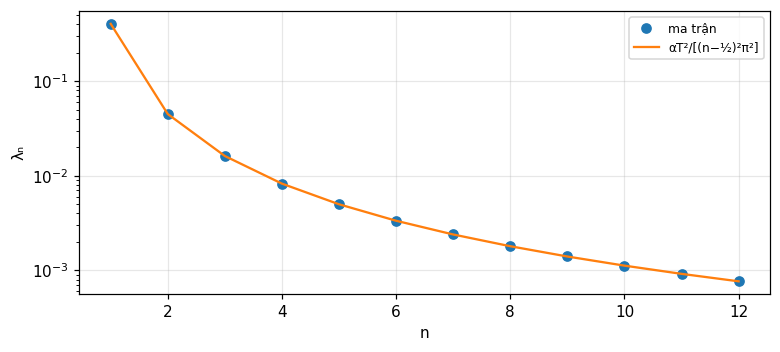

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 3.3))
nrange = np.arange(1, 13)
ax.semilogy(nrange, ew[:12], "o", label=("ma trận")); ax.semilogy(nrange, [lam_n(n_) for n_ in nrange], "-", label=r"αT²/[(n−½)²π²]")
ax.set_xlabel("n"); ax.set_ylabel("λₙ"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Nhân Green: 0.1013, 0.0253; Mercer 0.12 và 0.12; nhân $1-\max$: 0.4053. Ma trận: 0.00379 và 263.62. Wiener: 0.4053, 0.045, 0.0162, 0.0083; tổng 0.5; phương sai $X_1$ 0.409; tương quan 0; độ nhọn dư 0. Nhân mũ: 1.1493, 0.3909, bốn đầu chiếm 0.888. Nhiễu trắng: 1, 1, 0.